Self-Attention & Multihead Attention

> hand-wire dot-product attention for one token
> 
> scale to multi-head, plot per-head weight heatmaps
> 
> mask out future tokens, verify causal property

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import torch

## Simplified self-attention

1. Compute the attention scores as dot products between inputs
2. The attention weights are a normalized version of the attention scores
3. The context vectors are computed as a weighted sum over the inputs

In [2]:
import torch
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)

In [3]:
# Compute dot product of query with every other token to get attention scores
# For example here just using secodn input token as query, but in practice do this on all input tokens
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [4]:
# Normalize attention scores to add to 1 to get attention weights
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [6]:
# Calculate context vector z^2 
# weighted sum of all input vectors(embedded input tokens * corresponding attention weight)
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i] * x_i
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


In [7]:
# Generalize to compute attention weights for all input tokens
attn_scores = torch.empty(6, 6)
for i,x_i in enumerate(inputs):
    for j,x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [8]:
# Improve efficiency with matrix multiplication
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [9]:
# Normalize each row to sum to 1 using softmax
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [10]:
# Use attention weights to compute context vectors via matrix multiplication
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


## self-attention with trainable weights

Introducing Query, Key, and Value weight **matrices** which are used to project the input tokens into query, key, and value **vectors**.

In [11]:
x_2 = inputs[1]
d_in = inputs.shape[1] # input embedding size = 3
d_out = 2 # output embedding size = 2, usually d_in=d_ou, but they are different here for visualization purposes

In [13]:
# Initialize weight matrices
torch.manual_seed(123)

# nn.Parameter registers matrix as a "weight" which is trainable
# Requires_grad is false here to reduce clutter, set to true when training
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [14]:
# Compute query, key, and value vectors
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)

tensor([0.4306, 1.4551])


In [15]:
keys = inputs @ W_key
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


In [17]:
# Compute attention score for query2-key2 : dot product query and key
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [19]:
# Compute all attention scores for query 2(query 2 dot product with each key)
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [21]:
# Normalize with softmax, dividing attnetion scores by sqrt of embedding dimension of keys
# Do this to avoid small gradients
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [23]:
# Compute context vectors as weighted sum of attention weights * value vectors
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


In [30]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        # Compute query, key, value vectors
        query = x @ self.W_query
        key = x @ self.W_key
        value = x @ self.W_value

        # Compute attention scores for each query-key pair
        attn_scores = query @ key.T

        # Normalize attention scores to get attention weights
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)

        # Compute context vectors as weighted sums of attn weights * value vectors
        context_vec = attn_weights @ value

        return context_vec

In [31]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [43]:
# Improve implementation using PyTorch nn.linear layers, perform matrix mutiplication when bias units are disabled
# Also nn.linear has optimized initialization scheme than nn.Parameter
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        # Compute query, key, value vectors
        query = self.W_query(x)
        key = self.W_key(x)
        value = self.W_value(x)

        # Compute attention scores for each query-key pair
        attn_scores = query @ key.T

        # Normalize attention scores to get attention weights
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)

        # Compute context vectors as weighted sums of attn weights * value vectors
        context_vec = attn_weights @ value

        return context_vec

In [45]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


## Causal Attention

Mask future tokens to prevent model from accessing future information in the sequence, since each prediction should only depend on previous words.

In [46]:
# Print attention weights from selfattention_v2 object
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [48]:
# Print binary mask using PyTorch tril
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


We can set the zeros to negative infinity, which will get turned into zero by the softmax.

In [49]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [50]:
# Apply softmax to get masked attention weights
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [51]:
torch.manual_seed(123)

In [55]:
# Apply dropout to prefent overfitting
dropout = torch.nn.Dropout(0.2)
print(dropout(attn_weights))

tensor([[1.2500, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6896, 0.5604, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4750, 0.3871, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3448, 0.3075, 0.0000, 0.2899, 0.0000, 0.0000],
        [0.2719, 0.0000, 0.2480, 0.2359, 0.0000, 0.0000],
        [0.0000, 0.2079, 0.2082, 0.0000, 0.2082, 0.1911]],
       grad_fn=<MulBackward0>)


In [63]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out  = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))
        # Register buffer moves to appropriate device(CPU/GPU) with model, helpful during training

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        query = self.W_query(x)
        key = self.W_key(x)
        value = self.W_value(x)

        # Compute attention scores
        attn_scores = query @ key.transpose(1, 2) #  transpose dimensions 1 and 2, since we have batches of inputs keep the batch dimension as the first postiion

        # Apply mask
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf) # _ means done in place, avoid making unnecessary copies

        # Normalize to get attention weights
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        # Apply dropout
        attn_weights = dropout(attn_weights)

        # Compute context vector
        context_vec = attn_weights @ values

        return context_vec

In [64]:
batch = torch.stack((inputs, inputs), dim=0) # two inputs with 6 tokens each, each token embedding dim 3
print(batch.shape)

torch.Size([2, 6, 3])


In [66]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape) # Resulting context vector should be 3d vector with each token now represented by 2d embedding(out specified output size)

context_vecs.shape: torch.Size([2, 6, 2])


## Multi-Head Attention

Multi-head attention runs the attention mechanism multiple tiems in parallel to capture different representations and contexts of the input sequence.

First will build it the intuitive but inefficient way - stacking causal attention modules.
Then will implement the more computationally efficient way.

In [68]:
# Stacks causal attention modules and outputs the context vectors concatenated(d_out=2 would produce 4d context vector)
# Processes single head attention modules sequentially
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(
                d_in, d_out, context_length, dropout, qkv_bias
            )
            for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1) # Passes input vector x through each head, concatenates all context vectors

In [70]:
torch.manual_seed(123)
context_length = batch.shape[1] # numebr of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape) # Shape is [2 input texts, 6 tokens in each input, 4d embedding of each token]

tensor([[[0.2319, 1.1015, 0.2319, 1.1015],
         [0.3673, 1.1807, 0.1020, 0.4846],
         [0.4073, 1.1970, 0.3509, 0.8904],
         [0.3795, 1.0705, 0.3296, 0.8178],
         [0.2380, 0.5931, 0.2420, 0.6864],
         [0.3146, 0.7709, 0.3013, 0.8204]],

        [[0.0000, 0.0000, 0.2319, 1.1015],
         [0.1121, 0.5323, 0.3786, 1.1873],
         [0.4073, 1.1970, 0.1741, 0.4412],
         [0.3795, 1.0705, 0.3821, 1.0671],
         [0.2423, 0.6926, 0.1979, 0.4768],
         [0.2696, 0.7401, 0.2848, 0.7728]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


We can integrate the multi-head functionality within a single class(instead of causal + multi-head).  This class will split the input into multiple heads by reshaping the projected query, key, and value tensors, and then combining the results from the heads after computing attention.


In [81]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce projection dim to match desired output dim
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value= nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split matrix by adding a num_heads dimension
        # unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transposes (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3) # Compute dot product for each head
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights_dropout = self.dropout(attn_weights)

        context_vec = (attn_weights_dropout @ values).transpose(1, 2) # Tensor shape: (b, num_tokens, num_heads, head_dim)

        # Combine heads where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)
        return context_vec, attn_weights

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention_heads(attn_weights, batch_idx=0):
    # Detach from the computation graph and convert to a numpy array
    attn_matrix = attn_weights[batch_idx].detach().cpu().numpy()
    num_heads = attn_matrix.shape[0]
    
    # Set up the figure side-by-side
    fig, axes = plt.subplots(1, num_heads, figsize=(5 * num_heads, 5))
    if num_heads == 1:
        axes = [axes] # Handle the single-head edge case
        
    for i in range(num_heads):
        sns.heatmap(
            attn_matrix[i], 
            cmap='viridis', 
            ax=axes[i],
            annot=True,    # Shows the exact number in the box
            fmt=".2f",     # Rounds to 2 decimal places
            vmin=0.0,      # Attention is always between 0 and 1
            vmax=1.0,
            cbar=(i == num_heads - 1) # Only put the colorbar on the last plot
        )
        axes[i].set_title(f"Attention Head {i + 1}")
        axes[i].set_xlabel("Key Tokens")
        axes[i].set_ylabel("Query Tokens")
        
    plt.tight_layout()
    plt.show()

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


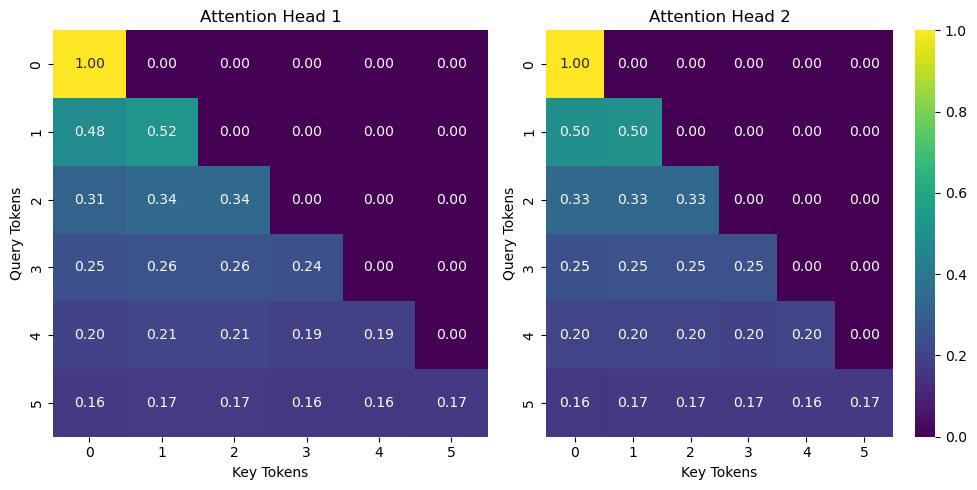

In [83]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2

mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs, weights = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

plot_attention_heads(weights)

You can see the values in the plots are slightly different, showing the different weight initializations.  During training the will be learned to attend to different representations of the inputs.